In [ ]:
from google.colab import files
uploaded = files.upload()

Saving analytical_result.csv to analytical_result.csv


In [46]:
from google.colab import files
uploaded = files.upload()

Saving instances_characteristics.csv to instances_characteristics.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [47]:
df_results = pd.read_csv('analytical_result.csv')
df_instances_characteristics = pd.read_csv('instances_characteristics.csv', sep=';', decimal=',')

df = pd.merge(df_results, df_instances_characteristics,
                    left_on='Instance',
                    right_on='Instância',
                    how='inner')

df = df.drop(columns=['Instância'])

display(df[['Instance', '|V|', '|E|', '|T|', 'D_G', 'C_T', 'GRASP_Cost_Avg', 'HUB_Cost_Avg']].head())

,Instance,|V|,|E|,|T|,D_G,C_T,GRASP_Cost_Avg,HUB_Cost_Avg
0,es100fst05.stp,188,238,100,0.013540,0.531915,75938545.4,75497806.4
1,es100fst07.stp,276,401,100,0.010567,0.362319,79544597.8,78418791.0
2,es100fst09.stp,248,342,100,0.011166,0.403226,79339298.2,78126200.2
3,es100fst10.stp,229,312,100,0.011951,0.436681,76050647.8,75540691.8
4,es100fst13.stp,254,361,100,0.011235,0.393701,76004696.2,75142333.3


In [54]:
df['Dataset'] = df['Instance'].str.replace(r'\d+\.stp$', '', regex=True)
df['Dataset'] = df['Dataset'].str.replace(r'-', '', regex=True)

def categorize_instance(name):
    name_lower = str(name).lower()
    if name_lower.startswith('es'):
        return 'Rectilinear'
    elif name_lower.startswith('i') or name_lower.startswith('b'):
        return 'Sparse'
    elif name_lower.startswith('wr'):
        return 'WireRouting'
    else:
        return 'VLSI'

df['Dataset_Type'] = df['Dataset'].apply(categorize_instance)

print(df['Dataset'].value_counts())

print("\n----------------------------------\n")

print(df['Dataset_Type'].value_counts())

print("\n----------------------------------\n")

print(f"Total: {len(df)}")

Dataset
i640        65
i320        52
i160        34
i080        20
b           18
es100fst     5
es50fst      5
es30fst      5
wrp3         5
diw          5
lin          4
wrp4         3
alut         2
alue         2
Name: count, dtype: int64

----------------------------------

Dataset_Type
Sparse         189
Rectilinear     15
VLSI            13
WireRouting      8
Name: count, dtype: int64

----------------------------------

Total: 225


In [69]:
df_merged = df.copy()

def get_winner_info(row):
    hub_cost = row['HUB_Cost_Avg']
    grasp_cost = row['GRASP_Cost_Avg']
    hub_time = row['HUB_Time_Avg_ms']
    grasp_time = row['GRASP_Time_Avg_ms']

    # Avalia Custo Médio primeiro
    if hub_cost < grasp_cost:
        return 'Hub', 'Custo'
    elif grasp_cost < hub_cost:
        return '1-Drop', 'Custo'
    else:
        # Empate no Custo, decide no Tempo Médio
        if hub_time < grasp_time:
            return 'Hub', 'Tempo'
        elif grasp_time < hub_time:
            return '1-Drop', 'Tempo'
        else:
            return 'Empate Absoluto', 'Empate'

# Aplica a função e cria duas novas colunas: Vencedor e Motivo
df_merged[['Vencedor', 'Motivo']] = df_merged.apply(get_winner_info, axis=1, result_type='expand')

# 4. Agrupar os dados e calcular Min/Max
grupos = df_merged.groupby('Dataset')
resultados = []

for nome, grupo in grupos:
    instancias = len(grupo)

    # Extração de Min e Max Topológicos (Formatados como string "[min, max]")
    min_v, max_v = int(grupo['|V|'].min()), int(grupo['|V|'].max())
    str_v = f"[{min_v}, {max_v}]" if min_v != max_v else f"{min_v}"

    min_e, max_e = int(grupo['|E|'].min()), int(grupo['|E|'].max())
    str_e = f"[{min_e}, {max_e}]" if min_e != max_e else f"{min_e}"

    min_t, max_t = int(grupo['|T|'].min()), int(grupo['|T|'].max())
    str_t = f"[{min_t}, {max_t}]" if min_t != max_t else f"{min_t}"

    min_dg, max_dg = grupo['D_G'].min(), grupo['D_G'].max()
    str_dg = f"[{min_dg:.3f}, {max_dg:.3f}]" if min_dg != max_dg else f"{min_dg:.3f}"

    min_ct, max_ct = grupo['C_T'].min(), grupo['C_T'].max()
    str_ct = f"[{min_ct:.2f}, {max_ct:.2f}]" if min_ct != max_ct else f"{min_ct:.2f}"

    # Melhoria Média e Intervalos
    hub_imp_mean = grupo['HUB_Improvement_Avg_%'].mean()
    hub_imp_min = grupo['HUB_Improvement_Avg_%'].min()
    hub_imp_max = grupo['HUB_Improvement_Avg_%'].max()
    str_hub_imp = f"{hub_imp_mean:.2f} [{hub_imp_min:.1f}, {hub_imp_max:.1f}]"

    grasp_imp_mean = grupo['GRASP_Improvement_Avg_%'].mean()
    grasp_imp_min = grupo['GRASP_Improvement_Avg_%'].min()
    grasp_imp_max = grupo['GRASP_Improvement_Avg_%'].max()
    str_grasp_imp = f"{grasp_imp_mean:.2f} [{grasp_imp_min:.1f}, {grasp_imp_max:.1f}]"

    tempo_hub = grupo['HUB_Time_Avg_ms'].mean()
    tempo_grasp = grupo['GRASP_Time_Avg_ms'].mean()

    # Contabilização de Vitórias
    hub_total = len(grupo[grupo['Vencedor'] == 'Hub'])
    hub_tempo = len(grupo[(grupo['Vencedor'] == 'Hub') & (grupo['Motivo'] == 'Tempo')])
    str_hub = f"{hub_total} ({hub_tempo} por tempo)" if hub_tempo > 0 else f"{hub_total}"
    if hub_total == 0: str_hub = "0"

    drop_total = len(grupo[grupo['Vencedor'] == '1-Drop'])
    drop_tempo = len(grupo[(grupo['Vencedor'] == '1-Drop') & (grupo['Motivo'] == 'Tempo')])
    str_drop = f"{drop_total} ({drop_tempo} por tempo)" if drop_tempo > 0 else f"{drop_total}"
    if drop_total == 0: str_drop = "0"

    empates = len(grupo[grupo['Vencedor'] == 'Empate Absoluto'])

    resultados.append({
        'Tipo' : grupo['Dataset_Type'].iloc[0],
        'Conjunto': nome,
        '|I|': instancias,
        '|V|': str_v,
        '|E|': str_e,
        '|T|': str_t,
        'D_G': str_dg,
        'C_T': str_ct,
        'Vit. (Hub)': str_hub,
        'Vit. (1-Drop)': str_drop,
        'Emp.': empates,
        'Melhoria 1-Drop (%) [Mín, Máx]': str_grasp_imp,
        'Melhoria HUB (%) [Mín, Máx]': str_hub_imp,
        'Tempo 1-Drop (ms)': f"{tempo_grasp:.1f}",
        'Tempo Hub (ms)': f"{tempo_hub:.1f}"
    })
tabela_final = pd.DataFrame(resultados)

# Ordenar primeiramente pelo Tipo (VLSI, Sparse, etc.) e depois pelo número de instâncias
tabela_final = tabela_final.sort_values(by=['Tipo', '|I|'], ascending=[False, False])

print(tabela_final[['Conjunto','|I|', 'Vit. (Hub)', 'Vit. (1-Drop)', 'Melhoria 1-Drop (%) [Mín, Máx]',  'Melhoria HUB (%) [Mín, Máx]']])

    Conjunto  |I|         Vit. (Hub)    Vit. (1-Drop)  \
12      wrp3    5    5 (1 por tempo)                0   
13      wrp4    3    3 (1 por tempo)                0   
3        diw    5    3 (1 por tempo)                2   
11       lin    4                  2                2   
0       alue    2                  2                0   
1       alut    2                  2                0   
10      i640   65  40 (36 por tempo)               25   
9       i320   52  37 (33 por tempo)               15   
8       i160   34  24 (22 por tempo)               10   
7       i080   20  19 (18 por tempo)                1   
2          b   18  12 (12 por tempo)                6   
4   es100fst    5                  5                0   
5    es30fst    5    3 (1 por tempo)  2 (1 por tempo)   
6    es50fst    5                  5                0   

   Melhoria 1-Drop (%) [Mín, Máx] Melhoria HUB (%) [Mín, Máx]  
12                0.00 [0.0, 0.0]             0.00 [0.0, 0.0]  
13              

/tmp/ipykernel_1354/3441851425.py:47: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_plot, x='D_G_Label', y='Tempo_ms', hue='Algoritmo', dodge=True, color='black', alpha=0.2, jitter=True, legend=False)


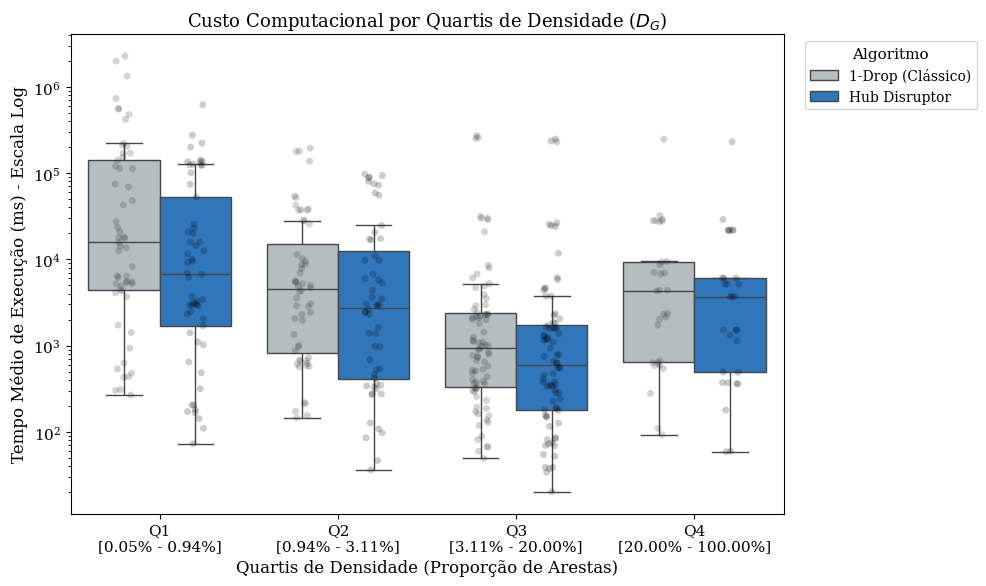

/tmp/ipykernel_1354/3441851425.py:62: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_plot, x='C_T_Label', y='Tempo_ms', hue='Algoritmo', dodge=True, color='black', alpha=0.2, jitter=True, legend=False)


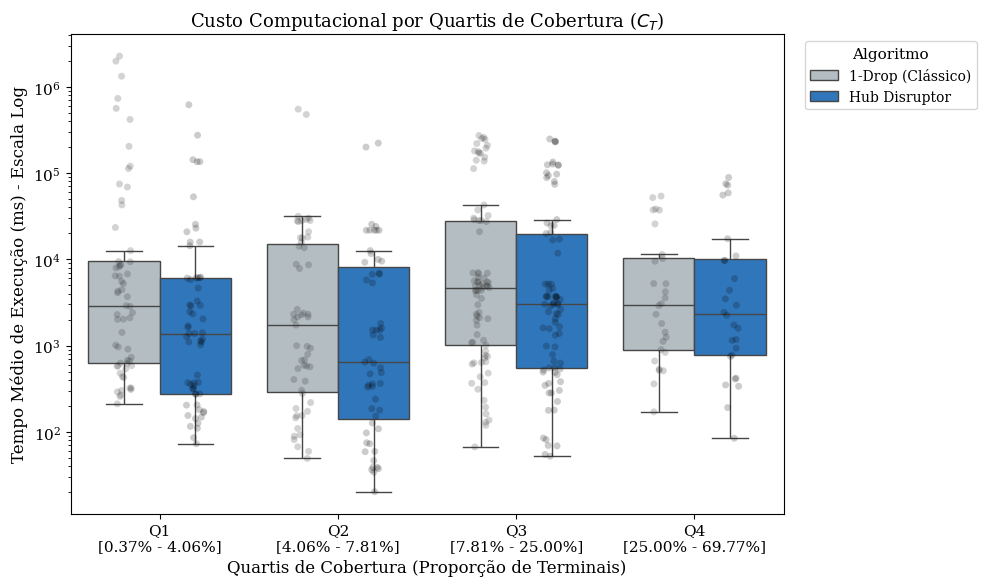

In [92]:
# Resetar e configurar estilo acadêmico
plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.autolayout': True
})

# ==========================================
# 1. CÁLCULO DOS QUARTIS DINÂMICOS
# ==========================================

# Quartis para Densidade (D_G)
df_merged['D_G_Quartil'], bins_dg = pd.qcut(df_merged['D_G'], q=4, retbins=True)
labels_dg = [f"Q{i+1}\n[{bins_dg[i]*100:.2f}% - {bins_dg[i+1]*100:.2f}%]" for i in range(4)]
df_merged['D_G_Label'] = pd.qcut(df_merged['D_G'], q=4, labels=labels_dg)

# Quartis para Cobertura (C_T)
df_merged['C_T_Quartil'], bins_ct = pd.qcut(df_merged['C_T'], q=4, retbins=True)
labels_ct = [f"Q{i+1}\n[{bins_ct[i]*100:.2f}% - {bins_ct[i+1]*100:.2f}%]" for i in range(4)]
df_merged['C_T_Label'] = pd.qcut(df_merged['C_T'], q=4, labels=labels_ct)

# ==========================================
# 2. PREPARAR DADOS PARA O PLOT (Tempo)
# ==========================================
df_plot = df_merged.melt(
    id_vars=['D_G_Label', 'C_T_Label'],
    value_vars=['GRASP_Time_Avg_ms', 'HUB_Time_Avg_ms'],
    var_name='Algoritmo', value_name='Tempo_ms'
)

df_plot['Algoritmo'] = df_plot['Algoritmo'].replace({
    'GRASP_Time_Avg_ms': '1-Drop (Clássico)',
    'HUB_Time_Avg_ms': 'Hub Disruptor'
})

cores = ['#B0BEC5', '#1976D2'] # Cinza e Azul

# ==========================================
# IMAGEM 1: Tempo por Quartis de Densidade
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='D_G_Label', y='Tempo_ms', hue='Algoritmo', palette=cores, showfliers=False)
sns.stripplot(data=df_plot, x='D_G_Label', y='Tempo_ms', hue='Algoritmo', dodge=True, color='black', alpha=0.2, jitter=True, legend=False)

plt.title('Custo Computacional por Quartis de Densidade ($D_G$)')
plt.xlabel('Quartis de Densidade (Proporção de Arestas)')
plt.ylabel('Tempo Médio de Execução (ms) - Escala Log')
plt.yscale('log')
plt.legend(title='Algoritmo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig('boxplot_tempo_quartis_densidade.pdf', bbox_inches='tight')
plt.show()

# ==========================================
# IMAGEM 2: Tempo por Quartis de Cobertura
# ==========================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x='C_T_Label', y='Tempo_ms', hue='Algoritmo', palette=cores, showfliers=False)
sns.stripplot(data=df_plot, x='C_T_Label', y='Tempo_ms', hue='Algoritmo', dodge=True, color='black', alpha=0.2, jitter=True, legend=False)

plt.title('Custo Computacional por Quartis de Cobertura ($C_T$)')
plt.xlabel('Quartis de Cobertura (Proporção de Terminais)')
plt.ylabel('Tempo Médio de Execução (ms) - Escala Log')
plt.yscale('log')
plt.legend(title='Algoritmo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.savefig('boxplot_tempo_quartis_cobertura.pdf', bbox_inches='tight')
plt.show()